# Inspecting the full pipeline for the VAE

In [39]:
from __future__ import annotations
import numpy as np 
import matplotlib.pyplot as plt
import json
import os
import sys 
import tskit 
from pathlib import Path
import torch

In [40]:
PROJECT_ROOT = Path(os.getcwd()).parent if 'notebooks' in os.getcwd() else Path(os.getcwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [41]:
processed_data_path = Path('/sietch_colab/akapoor/PRS_Portability/experiments/IM_symmetric/processed_data/0/rep0')

In [42]:
# Let's look at the normalized discovery data
norm_discovery = np.load(f'{processed_data_path}/discovery_train.npy')
norm_discovery_val = np.load(f'{processed_data_path}/discovery_val.npy')

In [43]:
norm_discovery.shape

(4000, 7183)

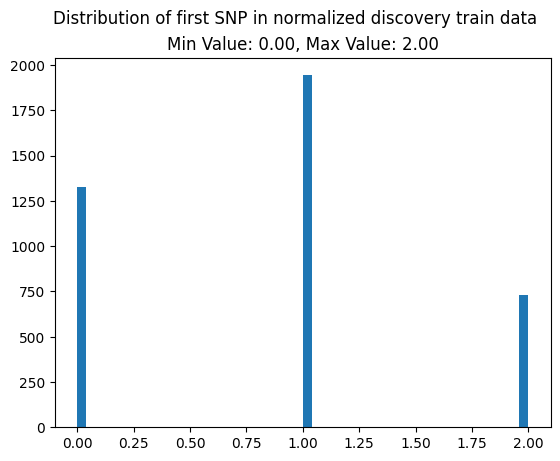

In [44]:
plt.figure()
plt.hist(norm_discovery[:,0], bins=50)
plt.suptitle('Distribution of first SNP in normalized discovery train data')
plt.title(f'Min Value: {norm_discovery[:,0].min():.2f}, Max Value: {norm_discovery[:,0].max():.2f}')
plt.show()

In [45]:
# Print the counts of each unique value in the first SNP column
unique, counts = np.unique(norm_discovery[:,0], return_counts=True)
print(f'Unique values in first SNP column: {unique}')
print(f'Counts of unique values: {counts}')

Unique values in first SNP column: [0. 1. 2.]
Counts of unique values: [1328 1944  728]


In [46]:
# Print the counts of each unique value across the entire train dataset
unique_all, counts_all = np.unique(norm_discovery, return_counts=True)
print(f'Unique values in entire dataset: {unique_all}')
print(f'Counts of unique values in entire dataset: {counts_all}')
print(f'Frequencies of unique values in entire train dataset: {counts_all / norm_discovery.size}')

Unique values in entire dataset: [0. 1. 2.]
Counts of unique values in entire dataset: [17049690  7938403  3743907]
Frequencies of unique values in entire train dataset: [0.59340422 0.27629135 0.13030443]


In [47]:
# Print the counts of each unique value across the entire train dataset
unique_all, counts_all = np.unique(norm_discovery_val, return_counts=True)
print(f'Unique values in entire dataset: {unique_all}')
print(f'Counts of unique values in entire dataset: {counts_all}')
print(f'Frequencies of unique values in entire validation dataset: {counts_all / norm_discovery_val.size}')

Unique values in entire dataset: [0. 1. 2.]
Counts of unique values in entire dataset: [4262364 1983347  937289]
Frequencies of unique values in entire validation dataset: [0.59339607 0.2761168  0.13048712]


In [48]:
from src.masking import make_mask_and_apply
x = torch.tensor(norm_discovery[:64], dtype=torch.float32)   # (B, L)

In [49]:
x_in, mask, used_block_len = make_mask_and_apply(
    x,
    enabled=True,
    n_blocks=12,
    block_len=None,
    mask_frac=0.10,
    allow_overlap=False,
    seed=123,
    fill="constant",
    gaussian_std=0.1,
    constant_value=-1.0,
)

print(x.shape, x_in.shape, mask.shape, used_block_len)

torch.Size([64, 7183]) torch.Size([64, 7183]) torch.Size([64, 7183]) 60


In [50]:
x

tensor([[1., 0., 0.,  ..., 0., 0., 1.],
        [1., 1., 0.,  ..., 1., 0., 1.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 1., 0.,  ..., 0., 0., 1.],
        [1., 0., 0.,  ..., 1., 0., 1.],
        [0., 1., 0.,  ..., 2., 0., 0.]])

In [51]:
x_in

tensor([[ 1.,  0.,  0.,  ...,  0.,  0.,  1.],
        [ 1.,  1.,  0.,  ...,  1.,  0.,  1.],
        [ 0.,  0.,  0.,  ..., -1., -1., -1.],
        ...,
        [ 0.,  1.,  0.,  ...,  0.,  0.,  1.],
        [ 1.,  0.,  0.,  ...,  1.,  0.,  1.],
        [ 0.,  1.,  0.,  ...,  2.,  0.,  0.]])

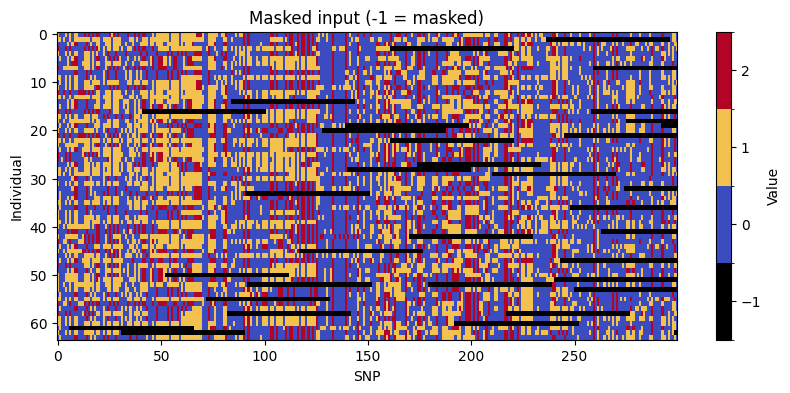

In [52]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# discrete colors for values: -1, 0, 1, 2
colors = [
    "black",     # -1 = masked
    "#3b4cc0",   # 0
    "#f2c14e",   # 1
    "#b40426",   # 2
]
cmap = ListedColormap(colors)
norm = BoundaryNorm([-1.5, -0.5, 0.5, 1.5, 2.5], cmap.N)

plt.figure(figsize=(10, 4))

subset = x_in[:, :300].cpu().numpy()   # first 300 SNPs

im = plt.imshow(
    subset,
    aspect="auto",
    cmap=cmap,
    norm=norm,
    interpolation="nearest",
)

cbar = plt.colorbar(im, ticks=[-1, 0, 1, 2])
cbar.set_label("Value")

plt.xlabel("SNP")
plt.ylabel("Individual")
plt.title("Masked input (-1 = masked)")
plt.show()

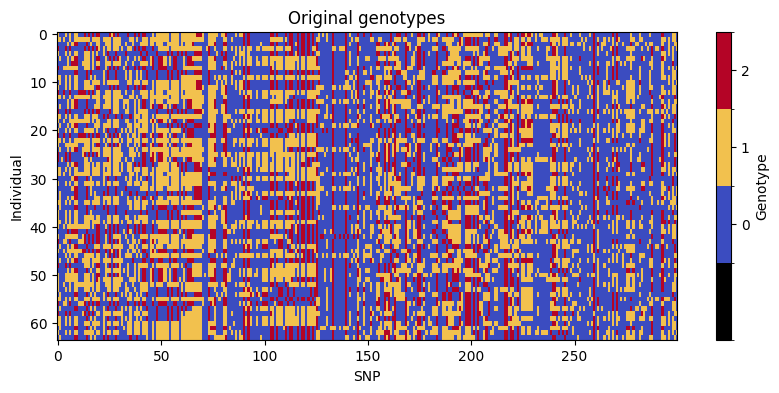

In [53]:
plt.figure(figsize=(10, 4))

subset = x[:, :300].cpu().numpy()

im = plt.imshow(
    subset,
    aspect="auto",
    cmap=cmap,
    norm=norm,
    interpolation="nearest",
)

cbar = plt.colorbar(im, ticks=[0, 1, 2])
cbar.set_label("Genotype")

plt.xlabel("SNP")
plt.ylabel("Individual")
plt.title("Original genotypes")
plt.show()

In [2]:
import numpy as np
from pathlib import Path

p = Path("/sietch_colab/akapoor/PRS_Portability/experiments/IM_symmetric/vae/default/0/rep0/recon/train_recon.npz")
d = np.load(p)

x_masked = d["x_masked"]
mask = d["mask"]

print("Unique values at masked positions:", np.unique(x_masked[mask])[:20])
print("Min/max at masked positions:", x_masked[mask].min(), x_masked[mask].max())
print("Unique values overall (small sample):", np.unique(x_masked)[:20])

Unique values at masked positions: [-1.]
Min/max at masked positions: -1.0 -1.0
Unique values overall (small sample): [-1.  0.  1.  2.]


In [5]:
import numpy as np
from pathlib import Path

def softmax(x, axis=1):
    x = x - np.max(x, axis=axis, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)

p = Path("/sietch_colab/akapoor/PRS_Portability/experiments/IM_symmetric/vae/default/0/rep0/recon/train_recon.npz")
d = np.load(p)

x_true = d["x_true"]
x_masked = d["x_masked"]
mask = d["mask"]
logits = d["recon"]   # shape (N, 3, L)

print("keys:", d.files)
print("x_true shape:", x_true.shape)
print("x_masked shape:", x_masked.shape)
print("mask shape:", mask.shape)
print("logits shape:", logits.shape)

probs = softmax(logits, axis=1)   # (N, 3, L)
pred = probs.argmax(axis=1)       # (N, L)

p0 = probs[:, 0, :]
p1 = probs[:, 1, :]
p2 = probs[:, 2, :]

print("\nOverall mean probs:")
print("P0:", p0.mean())
print("P1:", p1.mean())
print("P2:", p2.mean())

print("\nMasked mean probs:")
print("P0:", p0[mask].mean())
print("P1:", p1[mask].mean())
print("P2:", p2[mask].mean())

print("\nBy true class, all positions:")
for c in [0, 1, 2]:
    idx = (x_true == c)
    print(f"\nTrue class {c}, n={idx.sum()}")
    print(" mean P0:", p0[idx].mean())
    print(" mean P1:", p1[idx].mean())
    print(" mean P2:", p2[idx].mean())
    print(" pred counts:", np.bincount(pred[idx], minlength=3))

print("\nUnique values at masked positions in x_masked:")
print(np.unique(x_masked[mask])[:20])

print("\nMin/max masked input values:")
print(x_masked[mask].min(), x_masked[mask].max())

keys: ['x_true', 'x_masked', 'mask', 'recon']
x_true shape: (16, 7183)
x_masked shape: (16, 7183)
mask shape: (16, 7183)
logits shape: (16, 3, 7183)

Overall mean probs:
P0: 0.5948408
P1: 0.27512383
P2: 0.13003533

Masked mean probs:
P0: 0.5949619
P1: 0.27508885
P2: 0.1299493

By true class, all positions:

True class 0, n=68006
 mean P0: 0.5948449
 mean P1: 0.27512726
 mean P2: 0.13002788
 pred counts: [68006     0     0]

True class 1, n=32237
 mean P0: 0.594786
 mean P1: 0.27516106
 mean P2: 0.13005297
 pred counts: [32237     0     0]

True class 2, n=14685
 mean P0: 0.5949425
 mean P1: 0.27502638
 mean P2: 0.13003117
 pred counts: [14685     0     0]

Unique values at masked positions in x_masked:
[-1.]

Min/max masked input values:
-1.0 -1.0


Original x shape: torch.Size([64, 7183])
Unique values in x: tensor([0., 1., 2.])
Masked x_in shape: torch.Size([64, 7183])
Mask shape: torch.Size([64, 7183])
Used block length: 269
Actual mask fraction: 0.13824090361595154
Unique values in x_in: tensor([-1.,  0.,  1.,  2.])
Logits shape: torch.Size([64, 3, 7183])
Mu shape: torch.Size([64, 64, 1796])
Logvar shape: torch.Size([64, 64, 1796])
Predicted classes shape: torch.Size([64, 7183])
Confidence shape: torch.Size([64, 7183])


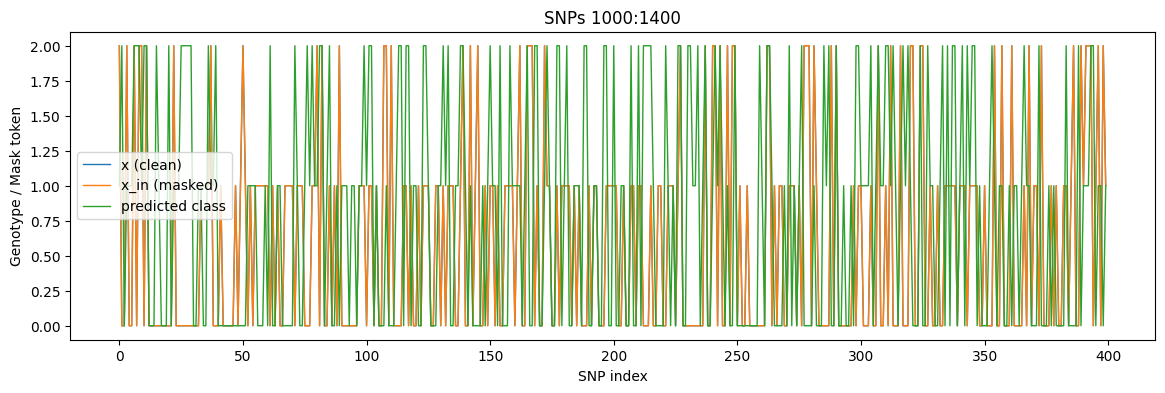

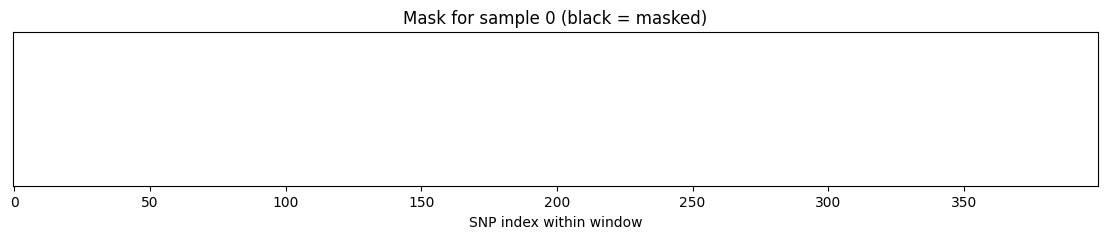

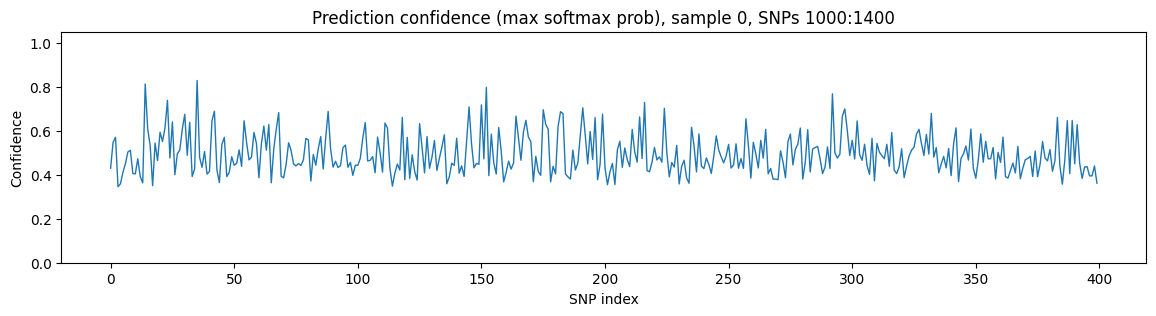

Masked accuracy (random weights): 0.37451809644699097
All-site accuracy (random weights): 0.38665512204170227


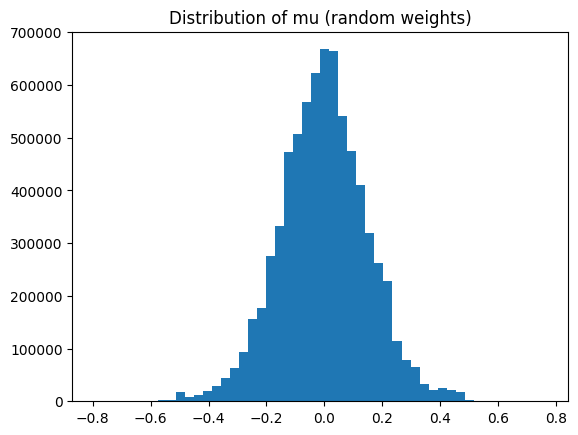

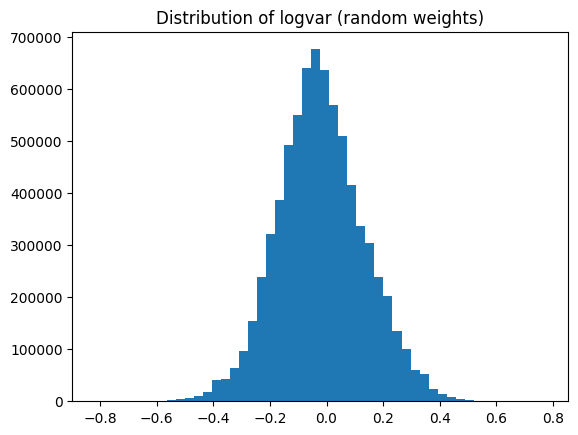

Input x: torch.Size([64, 7183])
Masked x_in: torch.Size([64, 7183])
Mask: torch.Size([64, 7183])
Logits: torch.Size([64, 3, 7183])
Pred classes: torch.Size([64, 7183])
Latent mu: torch.Size([64, 64, 1796])
Latent logvar: torch.Size([64, 64, 1796])
Latent channels: 64
Latent spatial length: 1796
Total latent dims per sample: 114944


In [55]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset

from src.vae.model import FullyConvVAE1D
from src.masking import make_mask_and_apply

# --------------------------------------------------
# 1. Build model
# --------------------------------------------------
input_len = norm_discovery.shape[1]

model = FullyConvVAE1D(
    input_len=input_len,
    latent_dim=64,              # interpreted as latent channels
    hidden_channels=(64, 128),
    kernel_size=17,
    stride=2,
    padding=8,
    use_batchnorm=False,
)

model.eval()

# --------------------------------------------------
# 2. Grab one batch
# --------------------------------------------------
X = torch.tensor(norm_discovery, dtype=torch.float32)
loader = DataLoader(TensorDataset(X), batch_size=64, shuffle=False)

batch = next(iter(loader))
x = batch[0]   # (B, L)

print("Original x shape:", x.shape)
print("Unique values in x:", torch.unique(x))

# --------------------------------------------------
# 3. Apply masking
# --------------------------------------------------
x_in, mask, used_block_len = make_mask_and_apply(
    x,
    enabled=True,
    n_blocks=4,
    block_len=None,
    mask_frac=0.15,
    allow_overlap=True,
    seed=123,
    fill="constant",         # recommended for raw 0/1/2 genotypes
    gaussian_std=0.1,        # ignored here
    constant_value=-1.0,
)

print("Masked x_in shape:", x_in.shape)
print("Mask shape:", mask.shape)
print("Used block length:", used_block_len)
print("Actual mask fraction:", mask.float().mean().item())
print("Unique values in x_in:", torch.unique(x_in))

# --------------------------------------------------
# 4. Forward pass
# --------------------------------------------------
with torch.no_grad():
    logits, mu, logvar = model(x_in)

print("Logits shape:", logits.shape)   # should be (B, 3, L)
print("Mu shape:", mu.shape)
print("Logvar shape:", logvar.shape)

# --------------------------------------------------
# 5. Convert logits to useful quantities
# --------------------------------------------------
with torch.no_grad():
    probs = torch.softmax(logits, dim=1)        # (B, 3, L)
    pred_class = torch.argmax(logits, dim=1)    # (B, L)
    prob_max = probs.max(dim=1).values          # (B, L)

print("Predicted classes shape:", pred_class.shape)
print("Confidence shape:", prob_max.shape)

# --------------------------------------------------
# 6. Pick one example row for visualization
# --------------------------------------------------
i = 0
x_i = x[i].cpu().numpy()
xin_i = x_in[i].cpu().numpy()
mask_i = mask[i].cpu().numpy()
pred_i = pred_class[i].cpu().numpy()
conf_i = prob_max[i].cpu().numpy()

# choose a window
start = 1000
end = 1400

# --------------------------------------------------
# 7. Plot clean vs masked vs predicted class
# --------------------------------------------------
plt.figure(figsize=(14, 4))
plt.plot(x_i[start:end], label="x (clean)", linewidth=1)
plt.plot(xin_i[start:end], label="x_in (masked)", linewidth=1)
plt.plot(pred_i[start:end], label="predicted class", linewidth=1)
plt.legend()
plt.title(f"SNPs {start}:{end}")
plt.xlabel("SNP index")
plt.ylabel("Genotype / Mask token")
plt.show()

# --------------------------------------------------
# 8. Plot mask explicitly
# --------------------------------------------------
plt.figure(figsize=(14, 2))
plt.imshow(mask_i[start:end][None, :], aspect="auto", cmap="gray_r", interpolation="nearest")
plt.title(f"Mask for sample {i} (black = masked)")
plt.xlabel("SNP index within window")
plt.yticks([])
plt.show()

# --------------------------------------------------
# 9. Plot prediction confidence
# --------------------------------------------------
plt.figure(figsize=(14, 3))
plt.plot(conf_i[start:end], linewidth=1)
plt.ylim(0, 1.05)
plt.title(f"Prediction confidence (max softmax prob), sample {i}, SNPs {start}:{end}")
plt.xlabel("SNP index")
plt.ylabel("Confidence")
plt.show()

# --------------------------------------------------
# 10. Check masked-site prediction accuracy on this random model
# --------------------------------------------------
target = x.long()
masked_acc = (pred_class[mask] == target[mask]).float().mean().item() if mask.any() else float("nan")
all_acc = (pred_class == target).float().mean().item()

print("Masked accuracy (random weights):", masked_acc)
print("All-site accuracy (random weights):", all_acc)

# --------------------------------------------------
# 11. Latent sanity checks
# --------------------------------------------------
plt.figure()
plt.hist(mu.detach().cpu().numpy().flatten(), bins=50)
plt.title("Distribution of mu (random weights)")
plt.show()

plt.figure()
plt.hist(logvar.detach().cpu().numpy().flatten(), bins=50)
plt.title("Distribution of logvar (random weights)")
plt.show()

# --------------------------------------------------
# 12. Shape summary
# --------------------------------------------------
print("Input x:", x.shape)                  # (B, L)
print("Masked x_in:", x_in.shape)          # (B, L)
print("Mask:", mask.shape)                 # (B, L)
print("Logits:", logits.shape)             # (B, 3, L)
print("Pred classes:", pred_class.shape)   # (B, L)
print("Latent mu:", mu.shape)              # (B, C, S)
print("Latent logvar:", logvar.shape)      # (B, C, S)
print("Latent channels:", mu.shape[1])
print("Latent spatial length:", mu.shape[2])
print("Total latent dims per sample:", mu.shape[1] * mu.shape[2])

In [56]:
pred_class

tensor([[0, 1, 0,  ..., 2, 2, 1],
        [1, 2, 1,  ..., 0, 0, 2],
        [1, 0, 0,  ..., 0, 2, 0],
        ...,
        [1, 0, 0,  ..., 1, 0, 1],
        [1, 2, 1,  ..., 2, 0, 0],
        [0, 0, 0,  ..., 1, 2, 0]])

## Lightning Model and train_vae

In [53]:
from types import SimpleNamespace
from src.vae.lit_model import LitVAE
import numpy as np, torch

hp = {
  "seed": 0,
  "model": dict(latent_dim=64, hidden_channels=[64,128], kernel_size=17, stride=2, padding=8, use_batchnorm=False),
  "training": dict(lr=3e-4, beta=1e-3, weight_decay=1e-5),
  "masking": dict(enabled=True, alpha_masked=1.0, n_blocks=4, allow_overlap=True,
                  mask_frac=0.001, block_len=None, fill="gaussian", gaussian_std=0.1, constant_value=0.0)
}

# pretend you loaded your npy already:
X = np.load("/sietch_colab/akapoor/PRS_Portability/experiments/IM_symmetric/processed_data/0/rep0/discovery_train.npy")
input_len = X.shape[1]

cfg = SimpleNamespace(
    input_len=input_len,
    latent_dim=hp["model"]["latent_dim"],
    hidden_channels=tuple(hp["model"]["hidden_channels"]),
    kernel_size=hp["model"]["kernel_size"],
    stride=hp["model"]["stride"],
    padding=hp["model"]["padding"],
    use_batchnorm=hp["model"]["use_batchnorm"],
    seed=hp["seed"],
    training=SimpleNamespace(**hp["training"]),
    masking=SimpleNamespace(**hp["masking"]),
)

lit = LitVAE(cfg)
print("cfg.training.beta =", lit._get_beta() if hasattr(lit, "_get_beta") else "no _get_beta")
print("mask enabled:", getattr(getattr(cfg, "masking", None), "enabled", None))
print("alpha_masked:", getattr(getattr(cfg, "masking", None), "alpha_masked", None))

cfg.training.beta = 0.001
mask enabled: True
alpha_masked: 1.0


In [54]:
x = torch.tensor(X[:64], dtype=torch.float32)
lit.eval()

# If you have _shared_step in LitVAE:
out = lit._shared_step((x,), batch_idx=0, stage="train")

print("Keys:", sorted(out.keys()))
for k in ["loss","recon_objective","kl","mse_masked","mse_unmasked","mse_clean_all","mask_frac","delta_in_l1"]:
    if k in out:
        print(k, float(out[k]))

Keys: ['delta_in_l1', 'kl', 'kl_clean', 'loss', 'mask_frac', 'mse_clean_all', 'mse_corrupt_all', 'mse_masked', 'mse_unmasked', 'ratio_masked_over_clean', 'recon_objective', 'used_block_len', 'x_in_max', 'x_max']
loss 1.9269851446151733
recon_objective 1.9259333610534668
kl 1.0517483949661255
mse_masked 1.9259333610534668
mse_unmasked 2.0061705112457275
mse_clean_all 2.009854793548584
mask_frac 0.0011347889667376876
delta_in_l1 0.0008286333759315312


In [55]:
from copy import deepcopy

cfg2 = deepcopy(cfg)

# alpha = 1.0 (pure inpainting)
cfg2.masking.alpha_masked = 1.0
lit1 = LitVAE(cfg2).eval()
o1 = lit1._shared_step((x,), batch_idx=0, stage="train")

# alpha = 0.0 (only unmasked loss)
cfg2.masking.alpha_masked = 0.0
lit0 = LitVAE(cfg2).eval()
o0 = lit0._shared_step((x,), batch_idx=0, stage="train")

print("alpha=1 recon_objective:", float(o1["recon_objective"]), "mse_masked:", float(o1["mse_masked"]))
print("alpha=0 recon_objective:", float(o0["recon_objective"]), "mse_unmasked:", float(o0["mse_unmasked"]))

alpha=1 recon_objective: 2.0426812171936035 mse_masked: 2.0426812171936035
alpha=0 recon_objective: 2.0097997188568115 mse_unmasked: 2.0097997188568115


## Trained model results

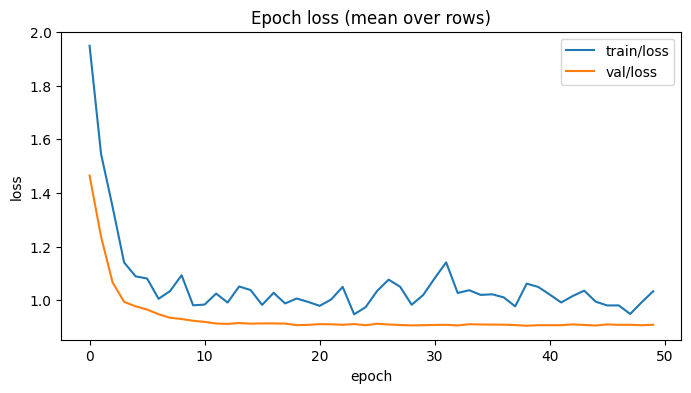

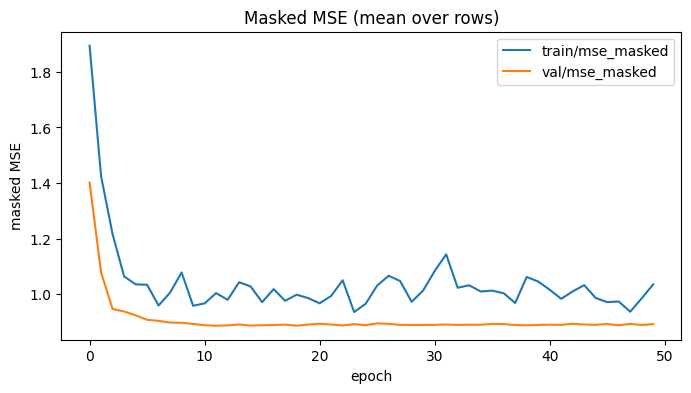

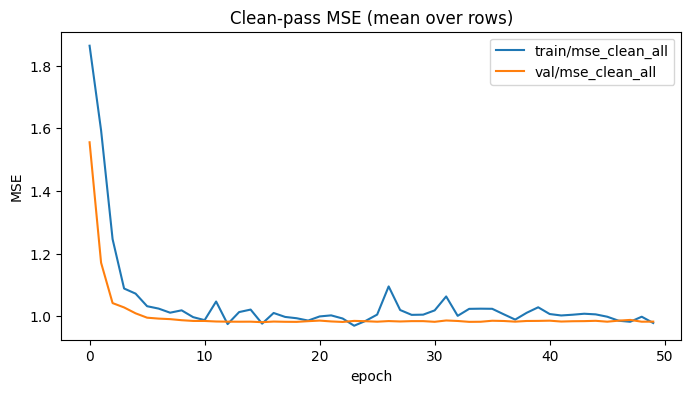

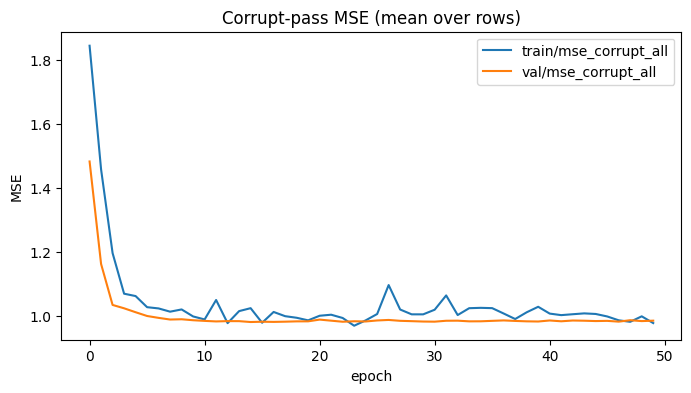

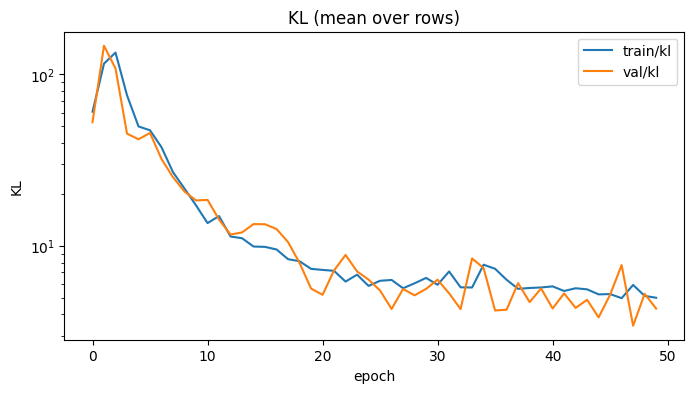

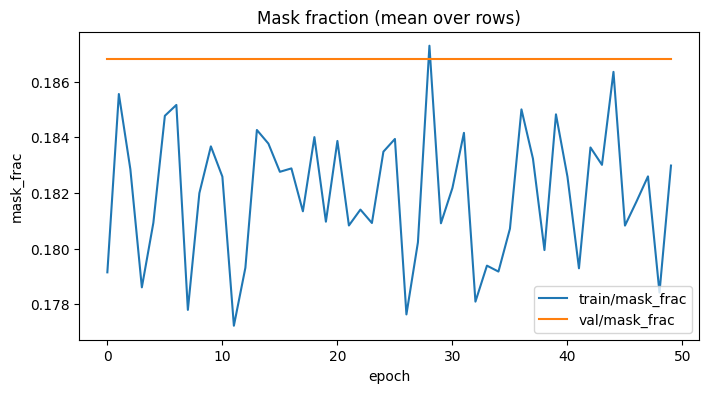

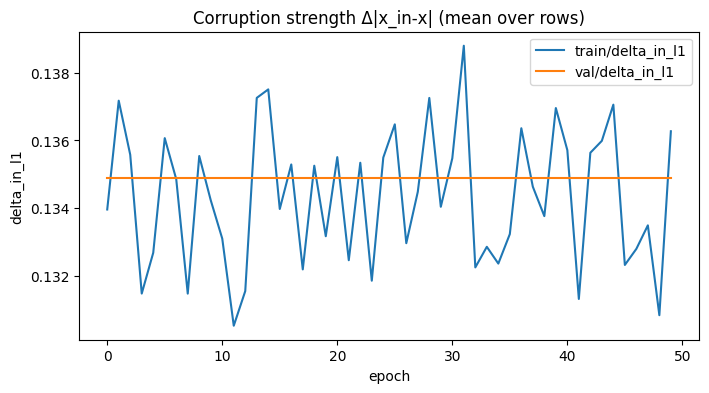

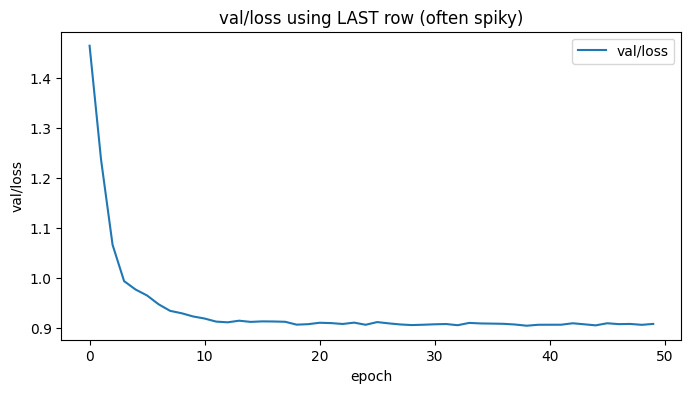

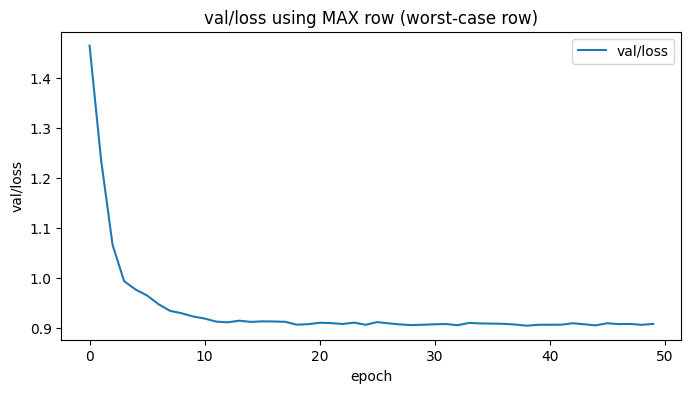

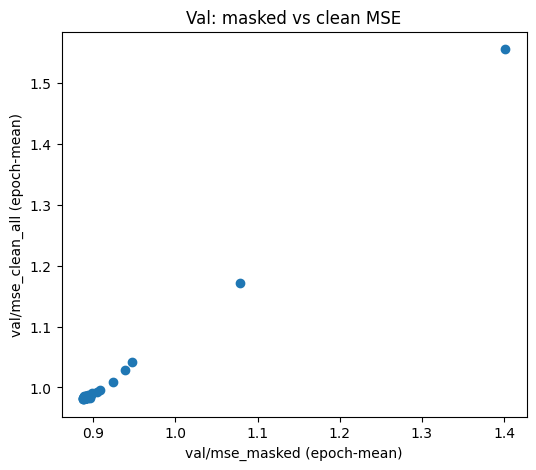

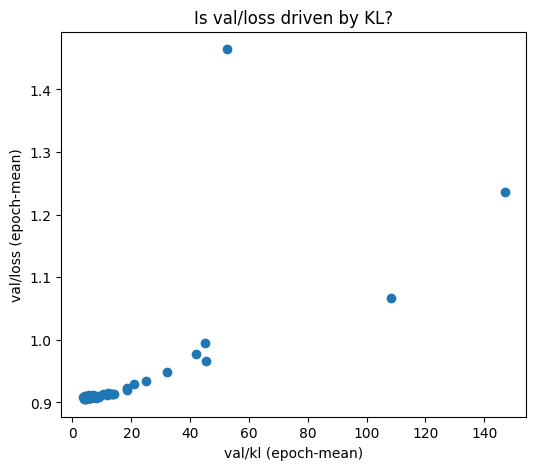

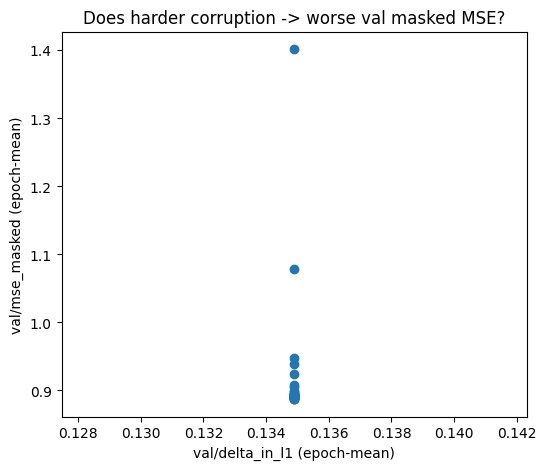

In [56]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

metrics_path = Path("/sietch_colab/akapoor/PRS_Portability/experiments/IM_symmetric/vae/default/0/rep0/logs/version_0/metrics.csv")
df = pd.read_csv(metrics_path)

# -----------------------------
# Helpers: robust epoch aggregation
# -----------------------------
def epoch_agg(cols, how="mean"):
    cols = [c for c in cols if c in df.columns]
    d = df[["epoch"] + cols].copy()
    d = d.dropna(subset=cols, how="all")

    g = d.groupby("epoch", as_index=False)

    if how == "mean":
        out = g[cols].mean(numeric_only=True)
    elif how == "median":
        out = g[cols].median(numeric_only=True)
    elif how == "max":
        out = g[cols].max(numeric_only=True)
    elif how == "last":
        out = g.last()
        out = out.reset_index()[["epoch"] + cols]
    else:
        raise ValueError("how must be one of: mean|median|max|last")

    return out.sort_values("epoch").reset_index(drop=True)

def plot_epoch(E, y1, y2=None, title=None, ylabel=None, logy=False):
    plt.figure(figsize=(8,4))
    plt.plot(E["epoch"], E[y1], label=y1)
    if y2 is not None and y2 in E.columns:
        plt.plot(E["epoch"], E[y2], label=y2)
    if logy:
        plt.yscale("log")
    plt.xlabel("epoch")
    plt.ylabel(ylabel if ylabel else y1)
    plt.title(title if title else f"{y1}" + (f" vs {y2}" if y2 else ""))
    plt.legend()
    plt.show()

# -----------------------------
# Choose metrics to inspect
# -----------------------------
cols = [
    "train/loss", "val/loss",
    "train/mse_masked", "val/mse_masked",
    "train/mse_clean_all", "val/mse_clean_all",
    "train/mse_corrupt_all", "val/mse_corrupt_all",
    "train/kl", "val/kl",
    "train/mask_frac", "val/mask_frac",
    "train/delta_in_l1", "val/delta_in_l1",  # how strong the corruption is
]

E_mean   = epoch_agg(cols, how="mean")
E_median = epoch_agg(cols, how="median")
E_max    = epoch_agg(cols, how="max")
E_last   = epoch_agg(cols, how="last")

# -----------------------------
# Core curves (MEAN is default)
# -----------------------------
plot_epoch(E_mean, "train/loss", "val/loss", title="Epoch loss (mean over rows)", ylabel="loss")
plot_epoch(E_mean, "train/mse_masked", "val/mse_masked", title="Masked MSE (mean over rows)", ylabel="masked MSE")
plot_epoch(E_mean, "train/mse_clean_all", "val/mse_clean_all", title="Clean-pass MSE (mean over rows)", ylabel="MSE")
if "train/mse_corrupt_all" in E_mean.columns and "val/mse_corrupt_all" in E_mean.columns:
    plot_epoch(E_mean, "train/mse_corrupt_all", "val/mse_corrupt_all", title="Corrupt-pass MSE (mean over rows)", ylabel="MSE")
plot_epoch(E_mean, "train/kl", "val/kl", title="KL (mean over rows)", ylabel="KL", logy=True)
plot_epoch(E_mean, "train/mask_frac", "val/mask_frac", title="Mask fraction (mean over rows)", ylabel="mask_frac")
if "train/delta_in_l1" in E_mean.columns and "val/delta_in_l1" in E_mean.columns:
    plot_epoch(E_mean, "train/delta_in_l1", "val/delta_in_l1", title="Corruption strength Δ|x_in-x| (mean over rows)", ylabel="delta_in_l1")

# -----------------------------
# Diagnostics: spikes due to aggregation?
# -----------------------------
plot_epoch(E_last, "val/loss", None, title="val/loss using LAST row (often spiky)", ylabel="val/loss")
plot_epoch(E_max,  "val/loss", None, title="val/loss using MAX row (worst-case row)", ylabel="val/loss")

# -----------------------------
# NEW: the diagnostic you asked for
# -----------------------------
# x-axis: val/mse_masked
# y-axis: val/mse_clean_all
plt.figure(figsize=(6,5))
plt.scatter(E_mean["val/mse_masked"], E_mean["val/mse_clean_all"])
plt.xlabel("val/mse_masked (epoch-mean)")
plt.ylabel("val/mse_clean_all (epoch-mean)")
plt.title("Val: masked vs clean MSE")
plt.show()

# Interpretation:
# - If val/mse_clean_all improves but val/mse_masked doesn't -> model is learning identity-ish recon, not inpainting.
# - If neither improves -> validation corruption/scale mismatch or real distribution shift.

# -----------------------------
# Extra: are val losses mostly KL-driven?
# -----------------------------
plt.figure(figsize=(6,5))
plt.scatter(E_mean["val/kl"], E_mean["val/loss"])
plt.xlabel("val/kl (epoch-mean)")
plt.ylabel("val/loss (epoch-mean)")
plt.title("Is val/loss driven by KL?")
plt.show()

# -----------------------------
# Extra: compare masking difficulty in val vs train
# -----------------------------
# If val is consistently harder (higher delta_in_l1 or higher mask_frac), val curves may not track train.
if "val/delta_in_l1" in E_mean.columns and "train/delta_in_l1" in E_mean.columns:
    plt.figure(figsize=(6,5))
    plt.scatter(E_mean["val/delta_in_l1"], E_mean["val/mse_masked"])
    plt.xlabel("val/delta_in_l1 (epoch-mean)")
    plt.ylabel("val/mse_masked (epoch-mean)")
    plt.title("Does harder corruption -> worse val masked MSE?")
    plt.show()

In [28]:
from pathlib import Path
import numpy as np

# -----------------------------
# Load your normalized arrays
# -----------------------------
root = Path("/sietch_colab/akapoor/PRS_Portability/experiments/IM_symmetric/processed_data/0/rep0")
X_train = np.load(root / "discovery_train.npy")   # (N_train, L)
X_val   = np.load(root / "discovery_val.npy")     # (N_val, L)

print("train:", X_train.shape, "val:", X_val.shape)
print("train mean/std:", X_train.mean(), X_train.std())
print("val   mean/std:", X_val.mean(), X_val.std())

# -----------------------------
# Mask helper (numpy version)
# matches your torch logic: pick random starts, make contiguous blocks, OR them
# -----------------------------
def make_multi_block_mask(B, L, block_len, n_blocks=1, seed=0, allow_overlap=True):
    rng = np.random.default_rng(seed)
    if block_len <= 0 or n_blocks <= 0:
        return np.zeros((B, L), dtype=bool)
    if block_len >= L:
        return np.ones((B, L), dtype=bool)

    mask = np.zeros((B, L), dtype=bool)

    if allow_overlap:
        starts = rng.integers(0, L, size=(B, n_blocks))
        for i in range(B):
            for b in range(n_blocks):
                s = int(starts[i, b])
                e = min(s + block_len, L)
                mask[i, s:e] = True
        return mask

    # best-effort non-overlap
    max_tries = 200
    for i in range(B):
        placed = 0
        tries = 0
        while placed < n_blocks and tries < max_tries:
            s = int(rng.integers(0, L))
            e = min(s + block_len, L)
            if not mask[i, s:e].any():
                mask[i, s:e] = True
                placed += 1
            tries += 1
    return mask

def resolve_block_len(L, block_len=None, mask_frac=None, n_blocks=1):
    if block_len is not None:
        return max(0, min(int(block_len), L))
    if mask_frac is None:
        return 0
    total = int(round(float(mask_frac) * L))
    total = max(1, min(total, L))
    per_block = int(round(total / int(n_blocks)))
    per_block = max(1, min(per_block, L))
    return per_block

def masked_mse(x, recon, mask, eps=1e-12):
    # x, recon: (B,L), mask bool: (B,L)
    diff2 = (recon - x) ** 2
    denom = mask.sum(axis=1, keepdims=True)  # (B,1)
    denom = np.maximum(denom, 1)            # avoid divide-by-zero
    per_sample = (diff2 * mask).sum(axis=1, keepdims=False) / denom[:, 0]
    return per_sample.mean()

# -----------------------------
# Baselines to compare against
# -----------------------------
def baseline_zero(x):
    return np.zeros_like(x)

def baseline_mean(x):
    # per-SNP mean within the *batch*; this is a strong baseline if things are standardized
    m = x.mean(axis=0, keepdims=True)
    return np.repeat(m, x.shape[0], axis=0)

# -----------------------------
# Run baseline evaluation
# -----------------------------
def eval_baselines(X, split_name, *, mask_frac=0.20, block_len=None, n_blocks=4, allow_overlap=True, seed=0):
    B, L = X.shape
    used_bl = resolve_block_len(L, block_len=block_len, mask_frac=mask_frac, n_blocks=n_blocks)
    mask = make_multi_block_mask(B, L, used_bl, n_blocks=n_blocks, seed=seed, allow_overlap=allow_overlap)
    frac_realized = mask.mean()

    recon0 = baseline_zero(X)
    reconm = baseline_mean(X)

    mse0 = masked_mse(X, recon0, mask)
    msem = masked_mse(X, reconm, mask)

    print(f"[{split_name}] L={L} used_block_len={used_bl} n_blocks={n_blocks} realized_mask_frac={frac_realized:.4f}")
    print(f"[{split_name}] baseline ZERO masked MSE : {mse0:.6f}")
    print(f"[{split_name}] baseline MEAN masked MSE : {msem:.6f}")
    return {"used_block_len": used_bl, "mask_frac": float(frac_realized), "mse_zero": float(mse0), "mse_mean": float(msem)}

# Use the same masking config you trained with:
cfg = dict(mask_frac=0.20, block_len=None, n_blocks=4, allow_overlap=True, seed=123)

train_base = eval_baselines(X_train, "train", **cfg)
val_base   = eval_baselines(X_val,   "val",   **cfg)

train: (400, 7036) val: (100, 7036)
train mean/std: 1.734939e-10 0.9997112
val   mean/std: 0.00021638854 1.0078791
[train] L=7036 used_block_len=352 n_blocks=4 realized_mask_frac=0.1798
[train] baseline ZERO masked MSE : 0.987841
[train] baseline MEAN masked MSE : 0.987841
[val] L=7036 used_block_len=352 n_blocks=4 realized_mask_frac=0.1806
[val] baseline ZERO masked MSE : 1.002112
[val] baseline MEAN masked MSE : 0.990776


In [29]:
# create mask for validation set

B, L = X_val.shape

block_len = 352
n_blocks = 4

mask = make_multi_block_mask(
    B,
    L,
    block_len,
    n_blocks=n_blocks,
    seed=123,
    allow_overlap=True
)

print("mask fraction:", mask.mean())

mask fraction: 0.1805955088118249


In [30]:
baseline_pred = np.zeros_like(X_val)

baseline_mse = masked_mse(X_val, baseline_pred, mask)

print("AF baseline masked MSE:", baseline_mse)

AF baseline masked MSE: 1.0021120071245846


In [31]:
rng = np.random.default_rng(0)

X_in = X_val.copy()

X_in[mask] = rng.normal(
    0,
    0.1,
    size=mask.sum()
)

In [32]:
import torch

model.eval()

with torch.no_grad():

    x_tensor = torch.tensor(X_in).float()

    recon, mu, logvar = model(x_tensor)

    recon = recon.cpu().numpy()

/sietch_colab/akapoor/PRS_Portability/src/vae/model.py:115: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=False):


In [34]:
model_mse = masked_mse(X_val, recon, mask)

print("AF baseline MSE:", baseline_mse)
print("Model masked MSE:", model_mse)

AF baseline MSE: 1.0021120071245846
Model masked MSE: 2.055653651845993


In [4]:
import numpy as np

x = np.load("/sietch_colab/akapoor/PRS_Portability/experiments/IM_symmetric/processed_data/0/rep0/discovery_val.npy")

x = np.rint(x).astype(int)

for c in [0, 1, 2]:
    print(c, (x == c).mean())

0 0.5933960740637617
1 0.2761168035639705
2 0.13048712237226787


In [9]:
import numpy as np
from pathlib import Path

npz_path = Path("/sietch_colab/akapoor/PRS_Portability/experiments/IM_symmetric/vae/vae__beta3e-5/0/rep0/recon/val_recon.npz")

d = np.load(npz_path)
print("keys:", list(d.keys()))

x_true = d["x_true"].astype(np.int64)
print("x_true shape:", x_true.shape)

if "pred" in d.files:
    pred = d["pred"].astype(np.int64)
    print("using saved 'pred'")
elif "recon" in d.files:
    recon = d["recon"]
    print("recon shape:", recon.shape)

    if recon.ndim == 3 and recon.shape[1] == 3:      # (N, 3, L)
        pred = recon.argmax(axis=1).astype(np.int64)
        print("derived pred from recon with shape (N, 3, L)")
    elif recon.ndim == 3 and recon.shape[-1] == 3:   # (N, L, 3)
        pred = recon.argmax(axis=2).astype(np.int64)
        print("derived pred from recon with shape (N, L, 3)")
    elif recon.ndim == 2:                            # (N, L) dosage
        pred = np.clip(np.rint(recon), 0, 2).astype(np.int64)
        print("derived pred from recon dosage with shape (N, L)")
    else:
        raise ValueError(f"Unsupported recon shape: {recon.shape}")
else:
    raise KeyError(f"No 'pred' or 'recon' found. Keys: {list(d.keys())}")

print("pred shape:", pred.shape)

if pred.shape != x_true.shape:
    raise ValueError(f"Shape mismatch: pred {pred.shape} vs x_true {x_true.shape}")

print("\nTrue class frequencies:")
for c in [0, 1, 2]:
    print(f"  class {c}: {(x_true == c).mean():.6f}")

print("\nPredicted class frequencies:")
for c in [0, 1, 2]:
    print(f"  class {c}: {(pred == c).mean():.6f}")

acc = (pred == x_true).mean()
print(f"\nAccuracy: {acc:.6f}")

recalls = []
for c in [0, 1, 2]:
    idx = (x_true == c)
    if idx.sum() == 0:
        continue
    recalls.append((pred[idx] == c).mean())
bal_acc = float(np.mean(recalls))
print(f"Balanced accuracy: {bal_acc:.6f}")

cm = np.zeros((3, 3), dtype=np.int64)
for t, p in zip(x_true.ravel(), pred.ravel()):
    if 0 <= t <= 2 and 0 <= p <= 2:
        cm[t, p] += 1

print("\nConfusion matrix (rows=true, cols=pred):")
print(cm)

keys: ['x_true', 'x_masked', 'mask', 'recon']
x_true shape: (16, 7183)
recon shape: (16, 3, 7183)
derived pred from recon with shape (N, 3, L)
pred shape: (16, 7183)

True class frequencies:
  class 0: 0.591727
  class 1: 0.280497
  class 2: 0.127776

Predicted class frequencies:
  class 0: 0.214821
  class 1: 0.327248
  class 2: 0.457930

Accuracy: 0.279549
Balanced accuracy: 0.337066

Confusion matrix (rows=true, cols=pred):
[[14775 22375 30856]
 [ 6901 10458 14878]
 [ 3013  4777  6895]]


In [10]:
import numpy as np

d = np.load("/sietch_colab/akapoor/PRS_Portability/experiments/IM_symmetric/vae/vae__beta3e-5/0/rep0/recon/val_recon.npz")
x_true = d["x_true"].astype(np.int64)
logits = d["recon"]  # (N, 3, L)

for c in [0, 1, 2]:
    idx = (x_true == c)
    print(f"\nTrue class {c}:")
    for k in [0, 1, 2]:
        print(f"  mean logit channel {k}: {logits[:, k, :][idx].mean():.6f}")


True class 0:
  mean logit channel 0: -0.172310
  mean logit channel 1: 0.032148
  mean logit channel 2: 0.251011

True class 1:
  mean logit channel 0: -0.177952
  mean logit channel 1: 0.018618
  mean logit channel 2: 0.258015

True class 2:
  mean logit channel 0: -0.196457
  mean logit channel 1: 0.018489
  mean logit channel 2: 0.269385


,beta,val_balanced_accuracy
0,0.000000e+00,1.0000
7,1.000000e-08,1.0000
13,3.000000e-08,1.0000
6,1.000000e-07,0.9999
12,3.000000e-07,0.9999
5,1.000000e-06,0.9997
11,3.000000e-06,0.9992
4,1.000000e-05,0.9968
10,3.000000e-05,0.9881
3,1.000000e-04,0.8109


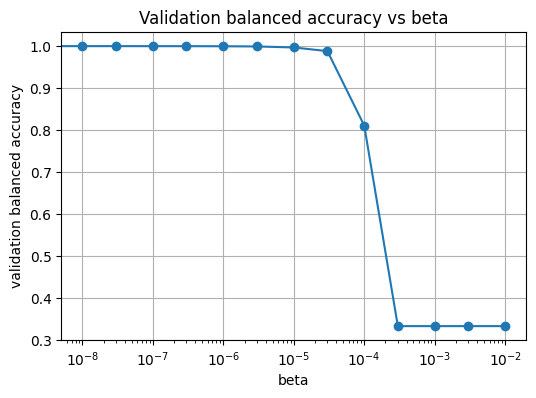

In [1]:
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

base = Path("/sietch_colab/akapoor/PRS_Portability/experiments/IM_symmetric/vae")

rows = []

for beta_dir in sorted(base.glob("vae__beta*")):
    beta_str = beta_dir.name.replace("vae__beta", "")
    beta = float(beta_str)

    summary = beta_dir / "0/rep0/diagnostics/balanced_accuracy_summary.txt"
    if not summary.exists():
        continue

    with open(summary) as f:
        for line in f:
            if line.startswith("val:"):
                m = re.search(r"bal_acc_all=([0-9.]+)", line)
                if m:
                    rows.append({
                        "beta": beta,
                        "val_balanced_accuracy": float(m.group(1))
                    })

df = pd.DataFrame(rows).sort_values("beta")

display(df)

plt.figure(figsize=(6,4))
plt.plot(df["beta"], df["val_balanced_accuracy"], marker="o")
plt.xscale("log")
plt.xlabel("beta")
plt.ylabel("validation balanced accuracy")
plt.title("Validation balanced accuracy vs beta")
plt.grid(True)
plt.show()